In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.integrate import odeint
import pandas as pd
import matplotlib.ticker as ticker 

#### Parameters

In [3]:
p = {
    'kk_1':  0.5,   
    'kk_2':  0.5,   
    'C50': 1.0,    
    'C_total': 2.0,
    'alpha_1': 0,
    'alpha_2': 0,
    'alpha_1_part': 0.5,
    'alpha_2_part': 0.5,
    'K':     1.0,    
    'beta':     0.2,    
    'mu':    0.1,    
    'rH':    0.1,   
    'rhor':  0.05,   
    'm':    3.2e-5  
}

#### Initial conditions

In [4]:
y0 = [0.95,     
      0.05,   
      0.0,
      0.0,
      0.0]   
t = np.linspace(0, 2000, 2000)

#### Transmission rates and fungicide efficacy

In [5]:
def Hills_function (C, kk, C50):
    if C <= 0:
        return 0.0
    return (kk * C/ (C + C50))

def dose_distribution(C_total, r_2):
    C_dose1 = C_total * (1 - r_2)
    C_dose2  = C_total * r_2
    return C_dose1, C_dose2 
    
C_dose1, C_dose2 = dose_distribution(p['C_total'], 0.5)

# Efficacies per fungicide
#scenario 1: alpha = 0
e_1 = Hills_function(C_dose1,p['kk_1'],p['C50'])
e_2 = Hills_function(C_dose2,p['kk_2'],p['C50'])

#scenario 1: alpha = 0.5
e_1_part = Hills_function(C_dose1,p['kk_1']*p['alpha_1_part'],p['C50'])
e_2_part= Hills_function(C_dose2,p['kk_2']*p['alpha_2_part'],p['C50'])

#transmission rates, scenario 1:  alpha = 0
b_ab = p['beta']*(1-e_1)*(1-e_2)
b_Ab = p['beta']*(1-p['rhor'])*(1-e_2)
b_aB = p['beta']*(1-e_1)*(1-p['rhor'])
b_AB = p['beta']*(1-p['rhor'])*(1-p['rhor'])

#transmission rates, scenario 2:  alpha = 0.5
b_ab_part = p['beta']*(1-e_1)*(1-e_2)
b_Ab_part = p['beta']*(1-e_1_part)*(1-e_2)*(1-p['rhor'])
b_aB_part= p['beta']*(1-e_1)*(1-e_2_part)*(1-p['rhor'])
b_AB_part= p['beta']*(1-e_1_part)*(1-e_2_part)*(1-p['rhor'])*(1-p['rhor'])

In [6]:
print("SCENARIO 1 (Full Resistance alpha=0)")
print(f"Sensitive (b_ab): {b_ab:.4f}")
print(f"Resistant to fungicide 1 (b_Ab): {b_Ab:.4f}")
print(f"Resistant to fungicide 2 (b_aB): {b_aB:.4f}")
print(f"Double Resistant (b_AB): {b_AB:.4f}")

print("SCENARIO 2 (Partial Resistance alpha=0.5)")
print(f"Sensitive (b_ab): {b_ab_part:.4f}")
print(f"Resistant to fungicide 1 (b_Ab): {b_Ab_part:.4f}")
print(f"Resistant to fungicide 2 (b_aB): {b_aB_part:.4f}")
print(f"Double Resistant (b_AB): {b_AB_part:.4f}")

SCENARIO 1 (Full Resistance alpha=0)
Sensitive (b_ab): 0.1125
Resistant to fungicide 1 (b_Ab): 0.1425
Resistant to fungicide 2 (b_aB): 0.1425
Double Resistant (b_AB): 0.1805
SCENARIO 2 (Partial Resistance alpha=0.5)
Sensitive (b_ab): 0.1125
Resistant to fungicide 1 (b_Ab): 0.1247
Resistant to fungicide 2 (b_aB): 0.1247
Double Resistant (b_AB): 0.1382


#### ODEs

In [7]:
def ODEs (y,t,p,b_ab, b_Ab, b_aB, b_AB):
    H, I_ab, I_Ab, I_aB, I_AB = y
    m = p['m']
    rH = p ['rH']
    K = p['K']
    mu = p['mu']

    dH = rH*(K - H - I_ab - I_Ab - I_aB - I_AB) - b_ab*I_ab*H - b_Ab*I_Ab*H - b_aB*I_aB*H - b_AB*I_AB*H
    dI_ab = (1-2*m)*b_ab*I_ab*H + m*b_Ab*I_Ab*H + m*b_aB*I_aB*H - mu*I_ab
    dI_Ab = m*b_ab*I_ab*H + (1-2*m)*b_Ab*I_Ab*H + m*b_AB*I_AB*H - mu*I_Ab
    dI_aB = m*b_ab*I_ab*H + (1-2*m)*b_aB*I_aB*H + m*b_AB*I_AB*H - mu*I_aB
    dI_AB = m*b_Ab*I_Ab*H + m*b_aB*I_aB*H + (1-2*m)*b_AB*I_AB*H - mu*I_AB

    return [dH, dI_ab, dI_Ab, dI_aB, dI_AB]

#### 90% threshold calculation for $I_{AB}$

In [8]:
def calculate_90_threshold (sol, t):
    I_total = sol[:,1] + sol[:,2] + sol[:,3] + sol[:,4]
    
    proportion_I_AB = np.divide(
        sol[:,4],
        I_total,
        out=np.zeros_like(I_total), 
        where = (I_total)!=0
    )
    
    indices = np.where(proportion_I_AB >= 0.9)[0]
    
    if len(indices) > 0:
        return t[indices[0]]
    else:
        return "Never"

#### Baseline scenario $I_{AB}$ 90% frequency ( No fungicide use)

In [9]:
def transmission_no_fungicide(p):
    b_ab = p['beta']
    b_Ab = p['beta'] * (1 - p['rhor'])
    b_aB = p['beta'] * (1 - p['rhor'])
    b_AB = p['beta'] * (1 - p['rhor'])*(1 - p['rhor'])

    return b_ab, b_Ab, b_aB, b_AB

b_no_fungicide = transmission_no_fungicide(p)
sol_no_fungicide = odeint(ODEs, y0, t, args=(p, *b_no_fungicide))

In [10]:
results = {
    'Scenario': ['No fungicide'],
    'Final I_AB': [
        sol_no_fungicide[-1, 4],
    ],
    'Time for 90% Dominance': [
        calculate_90_threshold(sol_no_fungicide, t),
    ]}

df = pd.DataFrame(results)

print(df.to_string(index=False))

    Scenario   Final I_AB Time for 90% Dominance
No fungicide 9.964591e-08                  Never


#### Modified scenario $I_{AB}$ 90% frequency ( with fungicide, alpha = 0.5)

In [11]:
def transmission_with_fungicide_05 (p):
    b_ab_part = p['beta']*(1-e_1)*(1-e_2)
    b_Ab_part = p['beta']*(1-e_1_part)*(1-e_2)*(1-p['rhor'])
    b_aB_part= p['beta']*(1-e_1)*(1-e_2_part)*(1-p['rhor'])
    b_AB_part= p['beta']*(1-e_1_part)*(1-e_2_part)*(1-p['rhor'])*(1-p['rhor'])
    
    return b_ab_part, b_Ab_part, b_aB_part, b_AB_part
    
b_w_fungicide_05 = transmission_with_fungicide_05 (p)
sol_w_fungicide_05 = odeint(ODEs, y0, t, args=(p, *b_w_fungicide_05))

In [12]:
results = {
    'Scenario': ['W_fungicide_05'],
    'Final I_AB' : [
        sol_w_fungicide_05[-1,4],
    ],
    'Time for 90% Dominance' : [
       calculate_90_threshold(sol_w_fungicide_05, t),
    ]}

df = pd.DataFrame (results)
print(df.to_string(index=False))

      Scenario  Final I_AB  Time for 90% Dominance
W_fungicide_05    0.138079              968.484242


#### Modified scenario $I_{AB}$ 90% frequency ( with fungicide, alpha = 0)

In [13]:
def transmission_with_fungicide_0 (p):
    b_ab = p['beta']*(1-e_1)*(1-e_2)
    b_Ab = p['beta']*(1-p['rhor'])*(1-e_2)
    b_aB = p['beta']*(1-e_1)*(1-p['rhor'])
    b_AB = p['beta']*(1-p['rhor'])*(1-p['rhor'])

    return b_ab, b_Ab, b_aB, b_AB
    
b_w_fungicide_0 = transmission_with_fungicide_0 (p)
sol_w_fungicide_0 = odeint(ODEs, y0, t, args=(p, *b_w_fungicide_0))

In [14]:
results = {
    'Scenario': ['W_fungicide_0'],
    'Final I_AB' : [
        sol_w_fungicide_0[-1,4],
    ],
    'Time for 90% Dominance' : [
       calculate_90_threshold(sol_w_fungicide_0, t),
    ]}
df = pd.DataFrame (results)
print(df.to_string(index=False))

     Scenario  Final I_AB  Time for 90% Dominance
W_fungicide_0    0.222906              388.194097


#### Table for Baseline scenario (No fungicide use)

In [15]:
df_time = pd.DataFrame({
    "Time": t,
    "H": sol_no_fungicide [:,0],
    "I_ab": sol_no_fungicide [:,1],
    "I_Ab": sol_no_fungicide [:,2],
    "I_aB": sol_no_fungicide [:,3],
    "I_AB": sol_no_fungicide [:,4]
})
#print (df_time.head(25))
print(df_time.head(50)) 

         Time         H      I_ab          I_Ab          I_aB          I_AB
0    0.000000  0.950000  0.050000  0.000000e+00  0.000000e+00  0.000000e+00
1    1.000500  0.940358  0.054658  3.292472e-07  3.292472e-07  1.884275e-12
2    2.001001  0.930414  0.059633  7.113839e-07  7.113839e-07  8.064524e-12
3    3.001501  0.920133  0.064929  1.150354e-06  1.150354e-06  1.937073e-11
4    4.002001  0.909484  0.070548  1.649898e-06  1.649898e-06  3.667880e-11
5    5.002501  0.898442  0.076487  2.213438e-06  2.213438e-06  6.089712e-11
6    6.003002  0.886992  0.082740  2.843967e-06  2.843967e-06  9.294978e-11
7    7.003502  0.875123  0.089295  3.543923e-06  3.543923e-06  1.337569e-10
8    8.004002  0.862835  0.096137  4.315077e-06  4.315077e-06  1.842143e-10
9    9.004502  0.850135  0.103245  5.158395e-06  5.158395e-06  2.451646e-10
10  10.005003  0.837039  0.110593  6.073951e-06  6.073951e-06  3.173753e-10
11  11.005503  0.823571  0.118149  7.060829e-06  7.060829e-06  4.015108e-10
12  12.00600

#### Table for Modified scenario (fungicide use, $\alpha$= 0.5)

In [16]:
df_time = pd.DataFrame({
    "Time": t,
    "H": sol_w_fungicide_05 [:,0],
    "I_ab": sol_w_fungicide_05 [:,1],
    "I_Ab": sol_w_fungicide_05 [:,2],
    "I_aB": sol_w_fungicide_05[:,3],
    "I_AB": sol_w_fungicide_05[:,4]
})
#print (df_time.head(25))
print(df_time.head(50)) 

         Time         H      I_ab          I_Ab          I_aB          I_AB
0    0.000000  0.950000  0.050000  0.000000e+00  0.000000e+00  0.000000e+00
1    1.000500  0.944893  0.050330  1.727409e-07  1.727409e-07  6.573492e-13
2    2.001001  0.940236  0.050635  3.486801e-07  3.486801e-07  2.663404e-12
3    3.001501  0.935990  0.050915  5.276661e-07  5.276661e-07  6.068537e-12
4    4.002001  0.932116  0.051174  7.095670e-07  7.095670e-07  1.092276e-11
5    5.002501  0.928584  0.051413  8.942695e-07  8.942695e-07  1.727600e-11
6    6.003002  0.925361  0.051634  1.081676e-06  1.081676e-06  2.517832e-11
7    7.003502  0.922422  0.051837  1.271705e-06  1.271705e-06  3.468021e-11
8    8.004002  0.919739  0.052025  1.464287e-06  1.464287e-06  4.583274e-11
9    9.004502  0.917292  0.052198  1.659365e-06  1.659365e-06  5.868768e-11
10  10.005003  0.915058  0.052358  1.856893e-06  1.856893e-06  7.329786e-11
11  11.005503  0.913019  0.052506  2.056833e-06  2.056833e-06  8.971722e-11
12  12.00600

#### Table for Modified scenario (fungicide use, $\alpha$ = 0.0)

In [17]:
df_time = pd.DataFrame({
    "Time": t,
    "H": sol_w_fungicide_0 [:,0],
    "I_ab": sol_w_fungicide_0 [:,1],
    "I_Ab": sol_w_fungicide_0 [:,2],
    "I_aB": sol_w_fungicide_0[:,3],
    "I_AB": sol_w_fungicide_0[:,4]
})
#print (df_time.head(25))
print(df_time.head(50)) 

         Time         H      I_ab          I_Ab          I_aB          I_AB
0    0.000000  0.950000  0.050000  0.000000e+00  0.000000e+00  0.000000e+00
1    1.000500  0.944893  0.050330  1.742101e-07  1.742101e-07  7.656917e-13
2    2.001001  0.940236  0.050635  3.546411e-07  3.546411e-07  3.162370e-12
3    3.001501  0.935989  0.050915  5.412667e-07  5.412667e-07  7.344929e-12
4    4.002001  0.932116  0.051174  7.340804e-07  7.340804e-07  1.347691e-11
5    5.002501  0.928584  0.051413  9.330946e-07  9.330946e-07  2.173132e-11
6    6.003002  0.925361  0.051634  1.138339e-06  1.138339e-06  3.229138e-11
7    7.003502  0.922421  0.051837  1.349859e-06  1.349859e-06  4.535172e-11
8    8.004002  0.919739  0.052025  1.567718e-06  1.567718e-06  6.111892e-11
9    9.004502  0.917291  0.052198  1.791990e-06  1.791990e-06  7.981263e-11
10  10.005003  0.915058  0.052358  2.022767e-06  2.022767e-06  1.016671e-10
11  11.005503  0.913018  0.052506  2.260150e-06  2.260150e-06  1.269319e-10
12  12.00600

#### Time series graph: time to 90% $I_{AB}$ frequency 

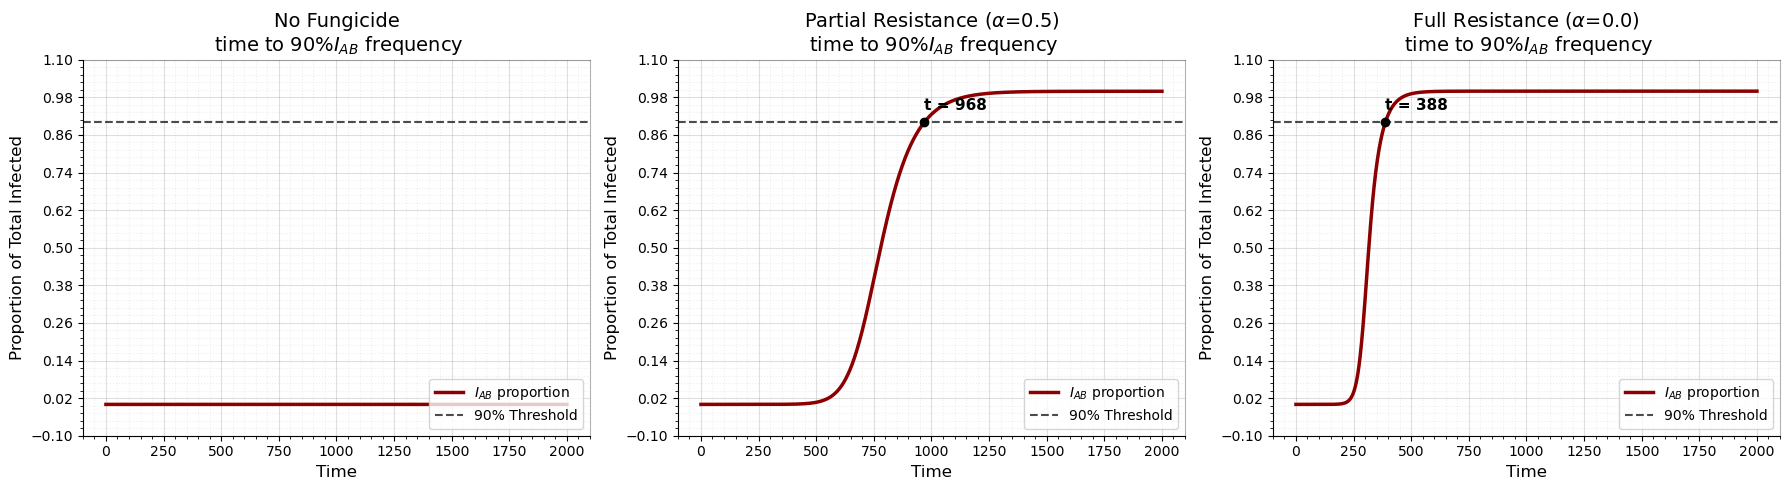

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

def calculate_I_AB_proportion(sol):
    I_total = sol[:, 1] + sol[:, 2] + sol[:, 3] + sol[:, 4]
    return np.divide(sol[:, 4], I_total, out=np.zeros_like(I_total), where=(I_total != 0))

scenarios = [
    ("No Fungicide", sol_no_fungicide),
    ("Partial Resistance ($\\alpha$=0.5)", sol_w_fungicide_05),
    ("Full Resistance ($\\alpha$=0.0)", sol_w_fungicide_0)
]

for i, (title, sol) in enumerate(scenarios):
    ax = axes[i]
    
    I_AB_proportion = calculate_I_AB_proportion(sol)

    ax.plot(t, I_AB_proportion, color='darkred', linewidth=2.5, label='$I_{AB}$ proportion')
    ax.axhline(y=0.9, color='black', linestyle='--', alpha=0.7, label='90% Threshold')

    indices = np.where(I_AB_proportion >= 0.9)[0]

    if len(indices) > 0:
        hit_time = t[indices[0]]
        ax.plot(hit_time, I_AB_proportion[indices[0]], 'ko')
        ax.text(hit_time, 0.94, f't = {hit_time:.0f}', fontsize=11, fontweight='bold')

    ax.set_title(title + "\n time to 90%$I_{AB}$ frequency ", fontsize=14)
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Proportion of Total Infected", fontsize=12)

    ax.set_ylim(-0.05, 1.1)
    ax.set_yticks(np.linspace(-0.1, 1.1, 11))
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)

    ax.minorticks_on()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    ax.grid(True, which='major', alpha=0.4)
    ax.grid(True, which='minor', alpha=0.2, linestyle=':')

    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)



plt.tight_layout()
plt.show()

#### Disease dynamics time graph

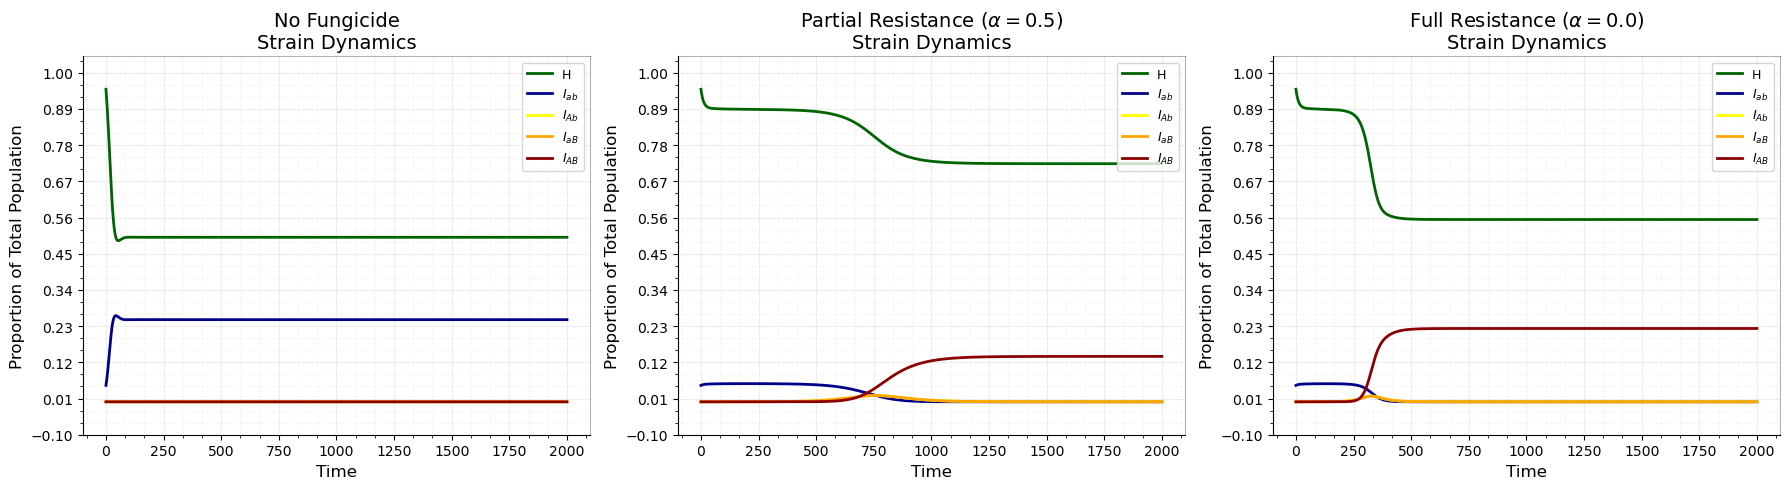

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

scenarios = [
    ("No Fungicide", sol_no_fungicide),
    ("Partial Resistance ($\\alpha=0.5$)", sol_w_fungicide_05),
    ("Full Resistance ($\\alpha=0.0$)", sol_w_fungicide_0)
]

labels = ['H', '$I_{ab}$', '$I_{Ab}$', '$I_{aB}$', '$I_{AB}$']
colors = ['darkgreen', 'darkblue', 'yellow', 'orange', 'darkred']

for i, (title, sol) in enumerate(scenarios):
    ax = axes[i]

    for j in range(5):
        ax.plot(t, sol[:, j], color=colors[j], linewidth=2, label=labels[j])

    ax.set_title(title + "\nStrain Dynamics", fontsize=14)
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Proportion of Total Population", fontsize=12)

    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks(np.linspace(-0.1, 1, 11))

    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)

    ax.minorticks_on()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))

    ax.grid(True, which='major', alpha=0.2)
    ax.grid(True, which='minor', alpha=0.2, linestyle = ':')

    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)
    
plt.tight_layout()
plt.show()